# Metodologia Design Science Research (DSR)\n\n**Etapas de Pesquisa (Peffers et al., 2007):**\n### 4. Demonstração (Demonstration)\n\n**Objetivo Acadêmico:** Este notebook avalia o modelo **Prophet (Meta)** como um artefato de predição robusto para dados de negócios. Na DSR, a demonstração visa aplicar o artefato para resolver instâncias do problema. O Prophet é testado aqui por sua capacidade nativa de lidar com feriados, sazonalidades complexas e gaps de dados (como o período de férias acadêmicas), validando sua eficácia como uma alternativa de alta performance e baixa manutenção em comparação a modelos estatísticos puristas.\n

# 07i - Modelagem: Prophet (Meta)
O **Prophet** é um modelo aditivo onde previsões de séries temporais são baseadas em tendências não lineares, sazonalidades (diária, semanal, anual) e efeitos de feriados.

**Diferencial**: Ele é muito robusto a dados faltantes (como nosso gap de Julho) e mudanças de tendência.

In [ ]:
import os
import sys
import logging

# 1. Configurações Globais de Encoding (Evita UnicodeDecodeError no Windows)
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["PYTHONUTF8"] = "1"

# 2. Silenciar Loggers Problemáticos (Causa raiz do AttributeError)
for name in ['prophet', 'cmdstanpy']:
    l = logging.getLogger(name)
    l.setLevel(logging.CRITICAL)
    l.propagate = False

from prophet import Prophet
import prophet.forecaster
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 3. Monkeypatch da classe Prophet para lidar com falhas de inicialização no Windows
def robust_load_stan_backend(self, stan_backend=None):
    from prophet.models import StanBackendEnum
    try:
        backend_name = stan_backend if stan_backend else 'CMDSTANPY'
        # Tenta inicializar o backend
        self.stan_backend = StanBackendEnum.get_backend_class(backend_name)()
    except Exception as e:
        print(f"⚠️ Aviso: Falha parcial no backend {stan_backend if stan_backend else 'Default'}: {e}")
        # Garante que o atributo existe para não quebrar o log interno do Prophet
        if not hasattr(self, 'stan_backend'):
            self.stan_backend = None

# Substitui o método problemático
prophet.forecaster.Prophet._load_stan_backend = robust_load_stan_backend

print("🚀 Treinando Prophet (com patch de resiliência Windows)...")

try:
    # Tentativa padrão
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    m.add_regressor('total_reservas')
    m.add_regressor('dia_semana')
    m.fit(train)
except Exception as e:
    print(f"❌ Erro fatal no treinamento: {e}")
    raise e

future = m.make_future_dataframe(periods=len(test))
future['total_reservas'] = df_prophet['total_reservas'].values
future['dia_semana'] = df_prophet['dia_semana'].values

forecast = m.predict(future)
y_pred = forecast['yhat'].iloc[len(train):].values
y_true = test['y'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

df_res = pd.DataFrame([{'Modelo': 'Prophet', 'MAE': mae, 'RMSE': rmse, 'R2': r2}])
display(df_res)

# Salvar predições
df_out = pd.DataFrame({'data': test['ds'], 'real': y_true, 'pred_prophet': y_pred})
df_out.to_csv('../data/preds_prophet.csv', index=False)

# Visualização
fig1 = m.plot(forecast)
plt.title(f"Prophet Forecast - R2: {r2:.2f}")
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

11:02:36 - cmdstanpy - INFO - Chain [1] start processing


🚀 Treinando Prophet...


11:02:37 - cmdstanpy - INFO - Chain [1] done processing


,Modelo,MAE,RMSE,R2
0,Prophet,25.985275,39.388757,-0.018487


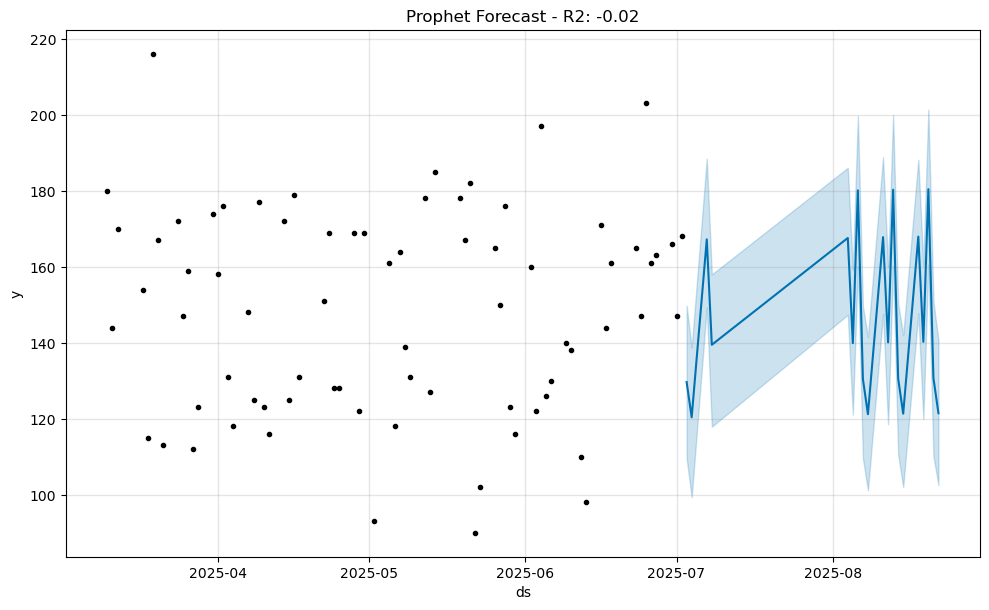

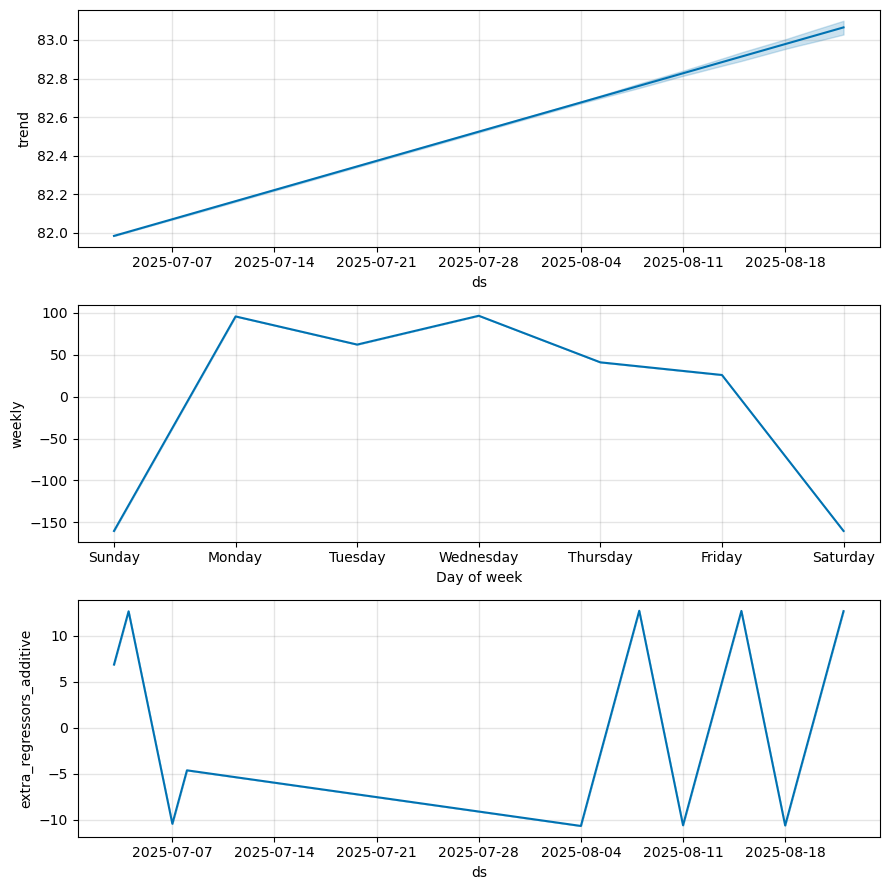

In [2]:
# 1. Instanciando e treinando o Prophet
m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
m.add_regressor('total_reservas')
m.add_regressor('dia_semana')

print("🚀 Treinando Prophet...")
m.fit(train)

# 2. Fazendo Predições
forecast = m.predict(test.drop(columns='y'))

# 3. Métricas
y_pred = forecast['yhat'].values
y_true = test['y'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

df_res = pd.DataFrame([{'Modelo': 'Prophet', 'MAE': mae, 'RMSE': rmse, 'R2': r2}])
display(df_res)

# Salvar predições
df_out = pd.DataFrame({'data': test['ds'], 'real': y_true, 'pred_prophet': y_pred})
df_out.to_csv('../data/preds_prophet.csv', index=False)

# Visualização
fig1 = m.plot(forecast)
plt.title(f"Prophet Forecast - R2: {r2:.2f}")
plt.show()

fig2 = m.plot_components(forecast)
plt.show()